In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False   # 解决负号方块

In [ ]:
import pandas as pd

file_path = r"data/情感结果.xlsx"

df = pd.read_excel(file_path)

# 数据预处理：1.筛选费城中餐厅 2.评论数≥100 3.删除期望落差缺失值
df_clean = df[
    (df['city'] == 'Philadelphia')  # 限定费城
    & (df['review_count'] >= 100)   # 保留有效评论样本
    & (df['expectation_gap'].notna())  # 排除期望落差缺失
].copy()

# 重置索引，便于后续处理
df_clean.reset_index(drop=True, inplace=True)

# 查看预处理后的数据（确认样本量）
print(f"有效样本数：{len(df_clean)}")
print(f"价格水平分布：\n{df_clean['price_level'].value_counts().sort_index()}")
print("\n数据前5行：")
print(df_clean[['name', 'price_level', 'stars', 'expectation_gap']].head())

有效样本数：100
价格水平分布：
price_level
1    14
2    70
3    10
4     6
Name: count, dtype: int64

数据前5行：
                               name  price_level  stars  expectation_gap
0           Reading Terminal Market            2    4.5         0.092687
1                    Dim Sum Garden            2    4.0         0.228670
2  Nan Zhou Hand Drawn Noodle House            2    4.0         0.281368
3                            Sampan            2    4.0         0.281368
4                          Buddakan            3    4.0         0.282704


In [4]:
def generate_pairwise_comparisons(data):
    """
    生成成对比较数据：同价格水平内，所有商家两两对比
    返回：comparisons列表，每个元素为(i,j)表示i优于j
    """
    comparisons = []
    # 按价格水平分组，组内生成配对
    for price in data['price_level'].unique():
        price_group = data[data['price_level'] == price].copy()
        price_group.reset_index(drop=True, inplace=True)
        n = len(price_group)
        
        # 遍历所有两两组合（i<j，避免重复）
        for i in range(n):
            for j in range(i+1, n):
                # 比较期望落差：i的期望落差小 → i优于j
                if price_group.loc[i, 'expectation_gap'] < price_group.loc[j, 'expectation_gap']:
                    comparisons.append((i, j))  # i→j（i优于j）
                else:
                    comparisons.append((j, i))  # j→i（j优于i）
    return comparisons

# 生成配对数据
pairwise_data = generate_pairwise_comparisons(df_clean)
print(f"\n生成成对比较数量：{len(pairwise_data)}")
print(f"前10组配对（i,j表示i优于j）：{pairwise_data[:10]}")


生成成对比较数量：2566
前10组配对（i,j表示i优于j）：[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (6, 0), (0, 7), (0, 8), (0, 9), (0, 10)]


In [4]:
def bt_log_likelihood(theta, comparisons):
    log_likelihood = 0
    # 加入L2正则化，防止参数发散
    reg = 1e-6 * np.sum(theta ** 2)
    for i, j in comparisons:
        prob = theta[i] / (theta[i] + theta[j])
        log_likelihood += np.log(prob + 1e-10)
    # 正则化惩罚项
    return -log_likelihood + reg

def estimate_bt_parameters(comparisons, n_players):
    initial_theta = np.ones(n_players)
    
    result = minimize(
        fun=bt_log_likelihood,
        x0=initial_theta,
        args=(comparisons,),
        method='L-BFGS-B',
        # 1. 增加上下界，防止发散
        bounds=[(1e-5, 1e6)] * n_players,
        # 2. 核心修复：扩容迭代/评估次数
        options={'maxiter': 50000, 'maxfun': 50000}
    )
    
    if result.success:
        return result.x
    else:
        raise ValueError("BT模型参数估计失败，原因：" + result.message)

有效餐厅数量：100
总配对数：2566

===== BT校正排序结果（前20） =====
                                 name         city  price_level  stars  expectation_gap   bt_quality  原始排名  BT校正排名  排名变化
                        Chubby Cattle Philadelphia            2    4.5         0.092687 9.996114e+01     1       1     0
              Reading Terminal Market Philadelphia            2    4.5         0.092687 3.883422e-02     1       2     1
New Leaf 2 Chinese & Japanese Cuisine Philadelphia            2    4.5         0.128930 2.942257e-05     1       3     2
                         LaTao HotPot Philadelphia            2    4.0         0.147180 3.270316e-08    12       4    -8
                    Andorra Ping Pong Philadelphia            2    4.0         0.152008 4.744532e-11    12       5    -7
                                I Tea Philadelphia            2    4.0         0.163982 8.466801e-14    12       6    -6
                     Dim Sum & Noodle Philadelphia            2    4.0         0.174015 1.775374e-16    1

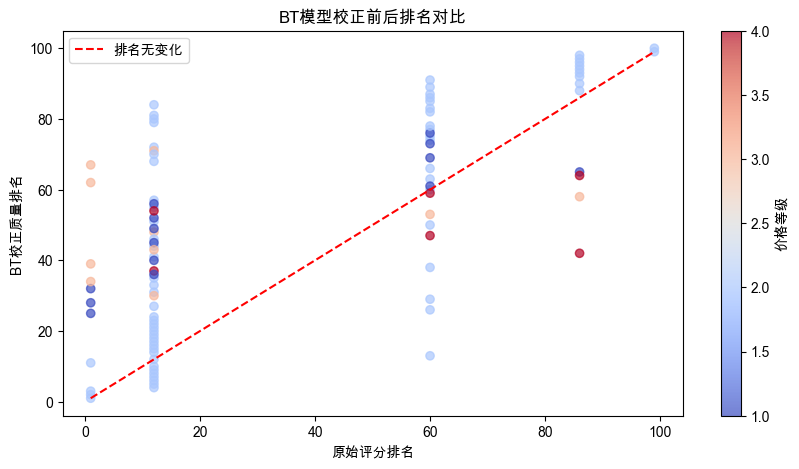

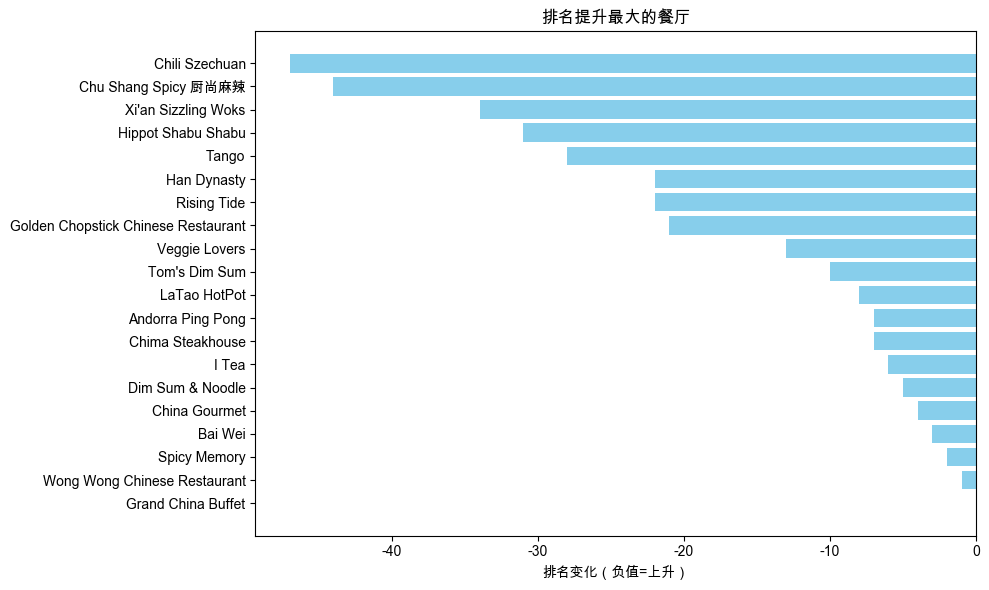


Spearman相关系数：0.658, P值：9.85e-14


In [5]:
# 筛选有效样本（评论数≥100，无缺失值）
df_clean = df[(df['review_count'] >= 100) & (df['expectation_gap'].notna())].copy()
df_clean = df_clean.reset_index(drop=True)
print(f"有效餐厅数量：{len(df_clean)}")

def generate_pairs(data):
    comparisons = []
    # 按城市+价格分组，控制异质性
    for _, group in data.groupby(['city', 'price_level']):
        indices = group.index.tolist()  # 使用原始索引
        n = len(indices)
        for a in range(n):
            for b in range(a+1, n):
                i = indices[a]
                j = indices[b]
                # 期望落差越小 → 质量越高 → i 优于 j
                if data.loc[i, 'expectation_gap'] < data.loc[j, 'expectation_gap']:
                    comparisons.append((i, j))
                else:
                    comparisons.append((j, i))
    return comparisons

pairwise = generate_pairs(df_clean)
print(f"总配对数：{len(pairwise)}")

def bt_loss(beta, comparisons, reg=1e-6):
    ll = 0
    for i, j in comparisons:
        ll += beta[i] - np.log(np.exp(beta[i]) + np.exp(beta[j]))
    ll -= reg * np.sum(beta**2)  # L2正则
    return -ll

def fit_bt(n_items, comparisons):
    # 初始值
    beta0 = np.zeros(n_items)
    # 优化
    res = minimize(
        fun=bt_loss,
        x0=beta0,
        args=(comparisons,),
        method='L-BFGS-B',
        options={'maxfun': 50000, 'maxiter': 50000}
    )
    if not res.success:
        raise Exception(f"优化失败：{res.message}")
    beta = res.x
    # 归一化处理（平均为1）
    theta = np.exp(beta)
    theta /= np.mean(theta)
    return theta

theta = fit_bt(len(df_clean), pairwise)
df_clean['bt_quality'] = theta

df_clean['原始排名'] = df_clean['stars'].rank(ascending=False, method='min').astype(int)
df_clean['BT校正排名'] = df_clean['bt_quality'].rank(ascending=False, method='min').astype(int)
df_clean['排名变化'] = df_clean['BT校正排名'] - df_clean['原始排名']

result = df_clean[['name','city','price_level','stars','expectation_gap',
                   'bt_quality','原始排名','BT校正排名','排名变化']]
print("\n===== BT校正排序结果（前20） =====")
print(result.sort_values('BT校正排名').head(20).to_string(index=False))

# 保存结果
result.sort_values('BT校正排名').to_excel("BT模型校正排序结果.xlsx", index=False)
print("\n✅ 结果已保存：BT模型校正排序结果.xlsx")

plt.figure(figsize=(10,5))
scatter = plt.scatter(df_clean['原始排名'], df_clean['BT校正排名'],
            c=df_clean['price_level'], cmap='coolwarm', alpha=0.7)
plt.plot([1, df_clean['原始排名'].max()], [1, df_clean['原始排名'].max()], 'r--', label='排名无变化')
plt.xlabel('原始评分排名')
plt.ylabel('BT校正质量排名')
plt.title('BT模型校正前后排名对比')
cbar = plt.colorbar(scatter)
cbar.set_label('价格等级')
plt.legend()
plt.savefig('BT排序对比图.png', dpi=300)
plt.show()

top_change = df_clean.sort_values('排名变化').head(20)
plt.figure(figsize=(10,6))
plt.barh(top_change['name'], top_change['排名变化'], color='skyblue')
plt.xlabel("排名变化（负值=上升）")
plt.title("排名提升最大的餐厅")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

corr, pval = spearmanr(df_clean['原始排名'], df_clean['BT校正排名'])
print(f"\nSpearman相关系数：{corr:.3f}, P值：{pval:.3g}")

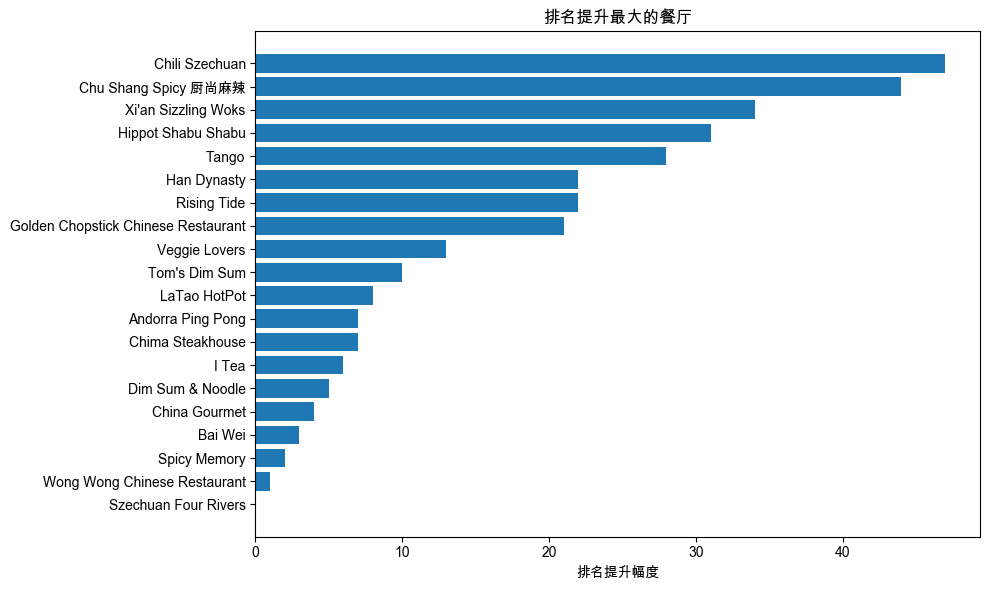

In [6]:
top_change = df_clean.copy()

# 提升幅度（越大越好）
top_change['提升幅度'] = df_clean['原始排名'] - df_clean['BT校正排名']

# 取提升最大的前20
top_change = top_change.sort_values('提升幅度', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top_change['name'], top_change['提升幅度'])
plt.xlabel("排名提升幅度")
plt.title("排名提升最大的餐厅")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()